In [3]:
#  Created by Samuel Prevost on 20/12/2018.
#  Copyright © 2016 Samuel Prevost. All rights reserved.

import math  # For cosine
import struct  # For WAVE file format
import time  # For timestamps
import wave  # For WAVE file format

import numpy as np  # For manipulating matrix
import scipy.ndimage  # For resampling
from PIL import Image  # For loading images
from pydub import AudioSegment  # For mixing two soundtracks
from tqdm import tqdm  # For progress bar


def load_image(file):
    img = Image.open(file)
    img = img.convert('L')

    img_arr = np.array(img)
    img_arr = np.flip(img_arr, axis=0)

    img_arr -= np.min(img_arr)
    img_arr = img_arr/np.max(img_arr)

    return img_arr


def resize_image(img_arr, size):
    if not size[0]:
        size[0] = img_arr.shape[0]
    if not size[1]:
        size[1] = img_arr.shape[1]

    resampling_factor = size[0]/img_arr.shape[0], size[1]/img_arr.shape[1]

    # Order : 0=nearestNeighbour, 1:bilinear, 2:cubic etc...
    img_arr = scipy.ndimage.zoom(img_arr, resampling_factor, order=0)

    return img_arr


def preprocess_image(img_arr):
    # Inverse filter
    # img_arr = 1 - img_arr
    return img_arr


def generate_soundwave(file, output='sound.wav', duration=2.5, sample_rate=44100.0, min_freq=0, max_freq=22000):
    waveform = wave.open(output, 'w')
    waveform.setnchannels(1)  # mono
    waveform.setsampwidth(2)
    waveform.setframerate(sample_rate)

    total_frame_count = int(duration * sample_rate)
    max_intensity = 32767  # Defined by WAV

    step_size = 100  # Works well in most cases
    substep_size = 250  # Works well in most cases

    freq_range = max_freq - min_freq
    stepping_spectrum = int(freq_range / step_size)

    img_arr = load_image(file)
    img_arr = preprocess_image(img_arr)
    img_arr = resize_image(img_arr, size=(stepping_spectrum, total_frame_count))

    img_arr *= max_intensity

    for frame in tqdm(range(total_frame_count)):
        signal_val, count = 0, 0

        for step in range(stepping_spectrum):
            intensity = img_arr[step, frame]

            current_freq = (step * step_size) + min_freq
            next_freq = ((step+1) * step_size) + min_freq

            if next_freq - min_freq > max_freq:  # End of the spectrum
                next_freq = max_freq

            for freq in range(current_freq, next_freq, substep_size):
                signal_val += intensity * math.cos(2 * math.pi * freq * frame/sample_rate)
                count += 1

        if count == 0:
            count = 1
        signal_val /= count

        data = struct.pack('<h', int(signal_val))
        waveform.writeframesraw(data)

    waveform.writeframes(''.encode())
    waveform.close()


def mix_soundtracks(file1, file2, output_file, start=0):
    sound1 = AudioSegment.from_file(file1)
    sound2 = AudioSegment.from_file(file2)

    # mix sound2 with sound1, starting at (start)ms into sound1)
    output = sound1.overlay(sound2, position=start)

    # save the result
    output.export(output_file, format=output_file.split('.')[-1])


def main():
    # Input files
    file = '/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg'
    music = '/Users/derrickvanfrausum/BeCode_AI/git-repos/Enter-the-pygame/gamecore/assets/sounds/genkidama.mp3'

    # Output files
    img_sound_output = 'outputs/img_sound{}.wav'.format(str(int(time.time()))[-5:])
    final_output = 'outputs/final_sound{}.wav'.format(str(int(time.time()))[-5:])

    generate_soundwave(file,
                       output=img_sound_output,
                       duration=10.5,
                       sample_rate=44100.0,
                       min_freq=16000,
                       max_freq=22000)

    print("Image to waveform ended successfully")
    mix_soundtracks(music, img_sound_output, final_output)
    print("Mixing ended successfully")
    print("Done.")


if __name__ == "__main__":
    main()

Exception ignored in: <function Wave_write.__del__ at 0x1183e41f0>
Traceback (most recent call last):
  File "/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/wave.py", line 326, in __del__
    self.close()
  File "/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/wave.py", line 443, in close
    if self._file:
AttributeError: 'Wave_write' object has no attribute '_file'
100%|██████████| 463050/463050 [00:15<00:00, 30676.57it/s]


Image to waveform ended successfully
Mixing ended successfully
Done.


In [ ]:
import wave, struct, math # To calculate the WAV file content
import numpy as np # To handle matrices
from PIL import Image # To open the input image and convert it to grayscale

import scipy.ndimage # To resample using nearest neighbour

'''
    Loads a picture, converts it to greyscale, then to numpy array, normalise it so that the max value is 1 
    the min is 0, increase the contrast a bit, remove every pixel which intensity is lower that 0.5, 
    then resize the picture using nearest neighbour resampling and outputs the numpy matrix.
    
    FYI: imgArr[0,0] is the top left corner of the image, cheers matrix indexing
    
    Returns: the resized image as a high contrast, normalised between 0 and 1, numpy matrix
'''
def loadPicture(size, file, contrast=True, highpass=False, verbose=1):
    img = Image.open(file)
    img = img.convert("L")
    #img = img.resize(size) # DO NOT DO THAT OR THE PC WILL CRASH
    
    imgArr = np.array(img)
    imgArr = np.flip(imgArr, axis=0)
    if verbose:
        print("Image original size: ", imgArr.shape)
        
    # Increase the contrast of the image
    if contrast:
        imgArr = 1/(imgArr+10**15.2) # Now only god knows how this works but it does
    else:
        imgArr = 1 - imgArr
    # Scale between 0 and 1
    imgArr -= np.min(imgArr)
    imgArr = imgArr/np.max(imgArr)
    # Remove low pixel values (highpass filter)
    if highpass:
        removeLowValues = np.vectorize(lambda x: x if x > 0.5 else 0, otypes=[np.float])
        imgArr = removeLowValues(imgArr)

    if size[0] == 0:
        size = imgArr.shape[0], size[1]
    if size[1] == 0:
        size = size[0], imgArr.shape[1]
    resamplingFactor = size[0]/imgArr.shape[0], size[1]/imgArr.shape[1]
    if resamplingFactor[0] == 0:
        resamplingFactor = 1, resamplingFactor[1]
    if resamplingFactor[1] == 0:
        resamplingFactor = resamplingFactor[0], 1
    
    # Order : 0=nearestNeighbour, 1:bilinear, 2:cubic etc...
    imgArr = scipy.ndimage.zoom(imgArr, resamplingFactor, order=0)
    
    if verbose:
        print("Resampling factor", resamplingFactor)
        print("Image resized :", imgArr.shape)
        print("Max intensity: ", np.max(imgArr))
        print("Min intensity: ", np.min(imgArr))
    return imgArr

def genSoundFromImage(file, output="sound.wav", duration=5.0, sampleRate=44100.0, intensityFactor=1, min_freq=0, max_freq=22000, invert=False, contrast=True, highpass=True, verbose=False):
    wavef = wave.open(output,'w')
    wavef.setnchannels(1) # mono
    wavef.setsampwidth(2) 
    wavef.setframerate(sampleRate)
    
    max_frame = int(duration * sampleRate)
    max_intensity = 32767 # Defined by WAV
    
    stepSize = 400 # Hz, each pixel's portion of the spectrum
    steppingSpectrum = int((max_freq-min_freq)/stepSize)
    
    imgMat = loadPicture(size=(steppingSpectrum, max_frame), file=file, contrast=contrast, highpass=highpass, verbose=verbose)
    if invert:
        imgMat = 1 - imgMat
    imgMat *= intensityFactor # To lower/increase the image overall intensity
    imgMat *= max_intensity # To scale it to max WAV audio intensity
    if verbose:
        print("Input: ", file)
        print("Duration (in seconds): ", duration)
        print("Sample rate: ", sampleRate)
        print("Computing each soundframe sum value..")
    for frame in range(max_frame):
        if frame % 60 == 0: # Only print once in a while
            print("Progress: ==> {:.2%}".format(frame/max_frame), end="\r")
        signalValue, count = 0, 0
        for step in range(steppingSpectrum):
            intensity = imgMat[step, frame]
            if intensity < 0.1*intensityFactor:
                continue
            # nextFreq is less than currentFreq
            currentFreq = (step * stepSize) + min_freq
            nextFreq = ((step+1) * stepSize) + min_freq
            if nextFreq - min_freq > max_freq: # If we're at the end of the spectrum
                nextFreq = max_freq
            for freq in range(currentFreq, nextFreq, 1000): # substep of 1000 Hz is good
                signalValue += intensity*math.cos(freq * 2 * math.pi * float(frame) / float(sampleRate))
                count += 1
        if count == 0: count = 1
        signalValue /= count
        
        data = struct.pack('<h', int(signalValue))
        wavef.writeframesraw( data )
        
    wavef.writeframes(''.encode())
    wavef.close()
    print("\nProgress: ==> 100%")
    if verbose:
        print("Output: ", output)

import sys
import argparse

def main(argv):
    parser = argparse.ArgumentParser()
    parser.add_argument("inputImage", help="Input image in any PIL supported format (JPG, PNG (with and without alpha), BMP etc...)")
    parser.add_argument("outputFile", help="path where to output the soundfile in WAV format")
    parser.add_argument("-d", "--duration", help="Duration of the sound to output, in whole seconds, default: 5", type=int)
    parser.add_argument("-n", "--minFreq", help="Minimum frequency to use, in Hz, default: 0", type=int)
    parser.add_argument("-x", "--maxFreq", help="Maximum frequency to use, in Hz, default: 22000", type=int)
    parser.add_argument("-s", "--samplerate", help="Sample rate of the sound to output, in Hertz, default: 44100", type=int)
    parser.add_argument("-if", "--intensityFactor", help="Factory by which multiply the image intensity, in decimal, default: 1.0", type=float)
    parser.add_argument("-i", "--invert", help="Invert the image intensity, resulting in an inverted spectrum", action="store_true")
    parser.add_argument("-c", "--contrast", help="Increases image's contrast before converting it, can enhance the resulting spectrum", action="store_true")
    parser.add_argument("-hi", "--highintensity", help="Cut low intensity pixels, can enhance result", action="store_true")
    parser.add_argument("-v", "--verbose", help="Display verbose", action="store_true")
    args = parser.parse_args()
    
    img = args.inputImage
    output = args.outputFile
    duration = 5 if not args.duration else args.duration
    min_freq = 0 if not args.minFreq else args.minFreq
    max_freq = 22000 if not args.maxFreq else args.maxFreq
    sampleRate = 44100 if not args.samplerate else args.samplerate
    intensityFactor = 1 if not args.intensityFactor else args.intensityFactor
    invert = args.invert
    contrast = args.contrast
    highpass = args.highintensity # Not a real highpass, but it cuts low intensities...
    verbose = args.verbose

    genSoundFromImage(
            file=img, 
            output=output, 
            duration=duration, 
            sampleRate=sampleRate,
            min_freq=min_freq,
            max_freq=max_freq,
            contrast=contrast, 
            invert=invert, 
            intensityFactor=intensityFactor,
            highpass=highpass, 
            verbose=verbose)

if __name__ == "__main__":
    main(sys.argv[1:])

In [4]:
import wave, struct, math # To calculate the WAV file content
import numpy as np # To handle matrices
from PIL import Image # To open the input image and convert it to grayscale

import scipy                     # To plot the spectrogram
import matplotlib.pyplot as plt  # To plot the spectrogram
import scipy.io.wavfile          # To plot the spectrogram

import scipy.ndimage # To resample using nearest neighbour
import IPython.display  # Jupyter notebook ...

In [5]:
def plotSpectrogram(file="sound.wav"):
    sample_rate, X = scipy.io.wavfile.read(file)
    plt.specgram(X, Fs=sample_rate, xextent=(0,60))
    print("File: ", file)
    print("Sample rate (Hz): ",sample_rate)

def plotMat(mat):
    mat = np.flip(mat,0)
    X, Y = np.meshgrid(range(mat.shape[0]), range(mat.shape[1]))
    Z = mat[X,Y]

    plt.pcolormesh(Y,X,Z)
    plt.show()

In [6]:
'''
    Loads a picture, converts it to greyscale, then to numpy array, normalise it so that the max value is 1 
    the min is 0, increase the contrast a bit, remove every pixel which intensity is lower that 0.5, 
    then resize the picture using nearest neighbour resampling and outputs the numpy matrix.
    
    FYI: imgArr[0,0] is the top left corner of the image, cheers matrix indexing
    
    Returns: the resized image as a high contrast, normalised between 0 and 1, numpy matrix
'''
def loadPicture(size, file, verbose=1):
    img = Image.open(file)
    img = img.convert("L")
    #img = img.resize(size) # DO NOT DO THAT OR THE PC WILL CRASH
    
    imgArr = np.array(img)
    if verbose:
        print("Image original size: ", imgArr.shape)
        
    # Increase the contrast of the image
    imgArr = imgArr/np.max(imgArr)
    imgArr = 1/(imgArr+10**15.2)
    
    # Scale between 0 and 1
    imgArr -= np.min(imgArr)
    imgArr = imgArr/np.max(imgArr)
    
    # Remove low pixel values
    removeLowValues = np.vectorize(lambda x: x if x > 0.5 else 0, otypes=[np.float])
    imgArr = removeLowValues(imgArr)
    
    if size[0] == 0:
        size = imgArr.shape[0], size[1]
    if size[1] == 0:
        size = size[0], imgArr.shape[1]
    resamplingFactor = size[0]/imgArr.shape[0], size[1]/imgArr.shape[1]
    if resamplingFactor[0] == 0:
        resamplingFactor = 1, resamplingFactor[1]
    if resamplingFactor[1] == 0:
        resamplingFactor = resamplingFactor[0], 1
    
    # Order : 0=nearestNeighbour, 1:bilinear, 2:cubic etc...
    imgArr = scipy.ndimage.zoom(imgArr, resamplingFactor, order=0)
    
    if verbose:
        print("Resampling factor", resamplingFactor)
        print("Image resized :", imgArr.shape)
        print("Max intensity: ", np.max(imgArr))
        print("Min intensity: ", np.min(imgArr))
        plotMat(imgArr)
    return imgArr

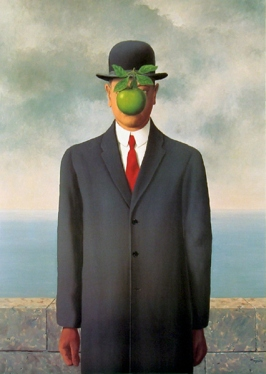

In [7]:
IPython.display.Image("/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg")

Image original size:  (374, 266)
Resampling factor (7.75668449197861, 8.646616541353383)
Image resized : (2901, 2300)
Max intensity:  1.0
Min intensity:  0.0


<ipython-input-6-b45b58098b20>:28: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  removeLowValues = np.vectorize(lambda x: x if x > 0.5 else 0, otypes=[np.float])
<ipython-input-5-21d528b1be7e>:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  plt.pcolormesh(Y,X,Z)


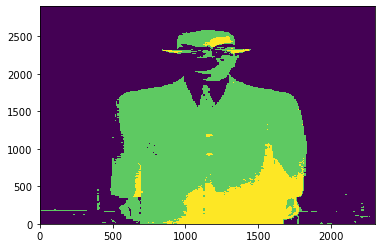

In [8]:
imgMat = loadPicture(size=(2901,2300), file="/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg")

In [9]:
def genSoundFromImage(file, output="sound.wav", duration=5.0, sampleRate=44100.0):
    wavef = wave.open(output,'w')
    wavef.setnchannels(1) # mono
    wavef.setsampwidth(2) 
    wavef.setframerate(sampleRate)
    
    max_frame = int(duration * sampleRate)
    max_freq = 22000 # Hz
    max_intensity = 32767
    
    stepSize = 400 # Hz
    steppingSpectrum = int(max_freq/stepSize)
    
    imgMat = loadPicture((steppingSpectrum, max_frame), file, verbose=0)
    imgMat *= max_intensity
    print("Input: ", file)
    print("Duration (in seconds): ", duration)
    print("Sample rate: ", sampleRate)
    print("Computing each soundframe sum value..")
    for frame in range(max_frame):
        if frame % 60 == 0: # Only print once in a while
            IPython.display.clear_output(wait=True)
            print("Progress: ==> {:.2%}".format(frame/max_frame), end="\r")
        signalValue, count = 0, 0
        for step in range(steppingSpectrum):
            intensity = imgMat[step, frame]
            if intensity == 0:
                continue
            # nextFreq is less than currentFreq
            currentFreq = max_freq - step * stepSize
            nextFreq = max_freq - (step+1) * stepSize
            if nextFreq < 0: # If we're at the end of the spectrum
                nextFreq = 0
            for freq in range(nextFreq, currentFreq, 1000): # substep of 1000 Hz is good
                signalValue += intensity*math.cos(freq * 2 * math.pi * float(frame) / float(sampleRate))
                count += 1
        if count == 0: count = 1
        signalValue /= count
        
        data = struct.pack('<h', int(signalValue))
        wavef.writeframesraw( data )
        
    wavef.writeframes(''.encode())
    wavef.close()
    print("\nProgress: ==> 100%")
    print("Output: ", output)

In [10]:
genSoundFromImage(file="/Users/derrickvanfrausum/BeCode_AI/git-repos/learn-ai/opencv/assets/images/magritte/Magritte_TheSonOfMan.jpg")

Progress: ==> 99.97%
Progress: ==> 100%
Output:  sound.wav


File:  sound.wav
Sample rate (Hz):  44100


/Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7723: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


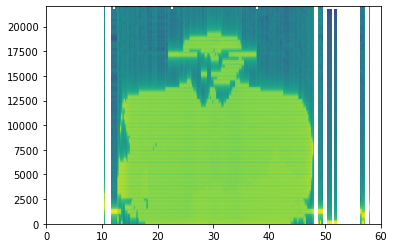

In [11]:
plotSpectrogram()

https://github.com/LeviBorodenko/spectrographic

In [2]:
!spectrographic --image /Users/derrickvanfrausum/Pictures/1516903619995.jpeg --min_freq 10000 --max_freq 20000 --duration 10 --save spectro_sound.wav --play

In [25]:
!spectrographic --image /Users/derrickvanfrausum/Pictures/1516903619995.jpeg --min_freq 0 --max_freq 20000 --duration 10 --save spectro_sound.wav --play

In [8]:
def plotSpectrogram(file="sound.wav"):
    sample_rate, X = scipy.io.wavfile.read(file)
    plt.specgram(X, Fs=sample_rate, xextent=(0,60))
    print("File: ", file)
    print("Sample rate (Hz): ",sample_rate)

In [14]:
import scipy.io.wavfile
import matplotlib.pyplot as plt

File:  spectro_sound.wav
Sample rate (Hz):  44100


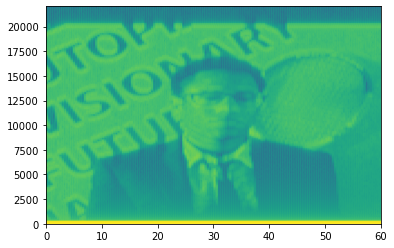

In [26]:
plotSpectrogram('spectro_sound.wav')